`Project 5:`

# **Titanic Survival Prediction**

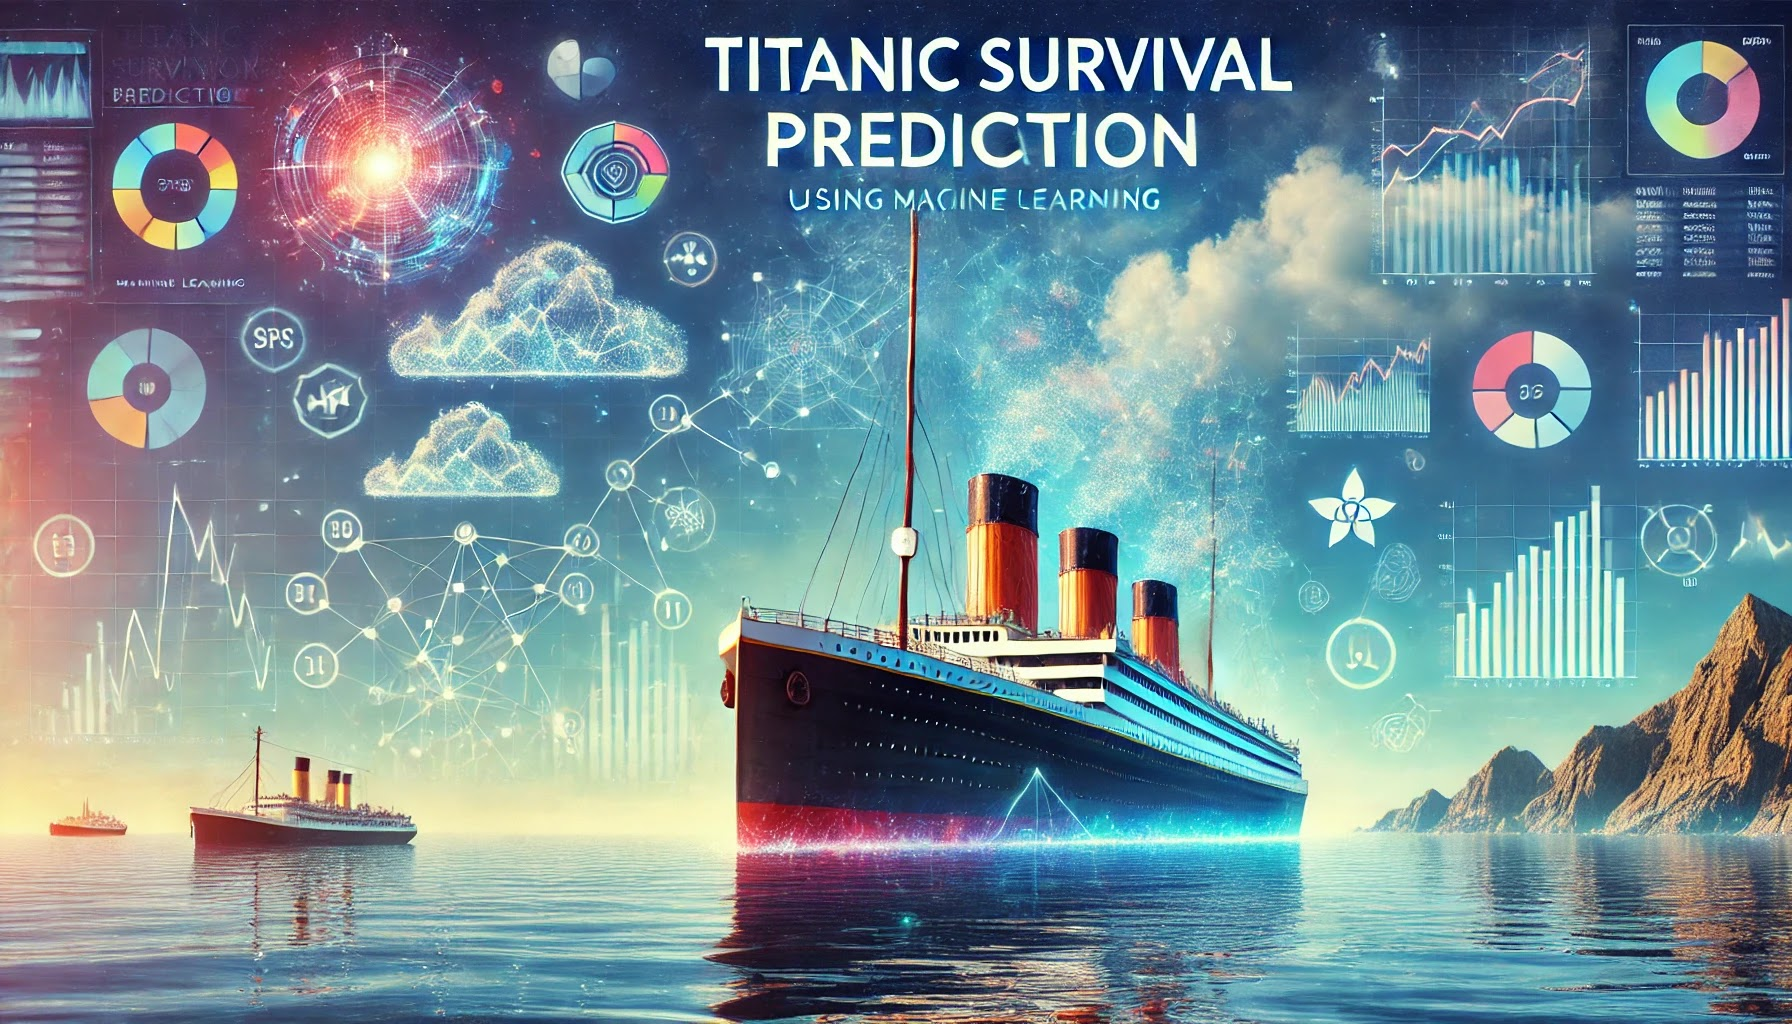

This project analyzes the Titanic passenger dataset to uncover patterns and factors that influenced survival during the historic disaster. By applying data preprocessing, exploratory data analysis (EDA), and machine learning techniques, the study aims to identify key determinants of survival and build a predictive model for classification.


**📊 STAGE 1: Dataset Overview**

Source: Kaggle
Timeline: Historical (1912 dataset)
Domain: Maritime Disaster Analysis

---

📌 **Dataset Feature Objectives**

* PassengerId → Unique identifier for each passenger
* Survived → Target variable (0 = Not Survived, 1 = Survived)
* Pclass → Passenger class (1st, 2nd, 3rd), indicates socio-economic status
* Name → Passenger name, useful for title extraction (Mr, Mrs, etc.)
* Sex → Gender of the passenger, key survival factor
* Age → Age of passenger, important demographic feature
* SibSp → Number of siblings/spouses aboard
* Parch → Number of parents/children aboard
* Ticket → Ticket number, used for grouping
* Fare → Ticket fare, indicates economic status
* Cabin → Cabin number (dropped due to high missing values)
* Embarked → Port of embarkation (C, Q, S)

---

🎯 **Objective**

To analyze passenger data and identify the key factors that influenced survival, and to build a machine learning model capable of predicting whether a passenger survived based on available features.

---

📈 **Outcomes**

Cleaned and preprocessed dataset by handling missing values
Identified key survival factors such as gender, fare, and passenger class
Generated visual insights through EDA and data visualization
Built and evaluated a classification model with strong predictive performance

---

🤖 **Types of Models**

1. **Classification Model**

🔹 Inputs (X):
Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

🔹 Output (Y):
Survived (0 = Not Survived, 1 = Survived)

---

⚙️ **Algorithms Used**

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier
* Gradient Boosting

# **INITIAL EDA :**

In [6]:
import pandas as pd

df = pd.read_csv("/content/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print(df.shape)
print(df.isnull().sum())
print(df.info())

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83

In [8]:
# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin column la romba missing irukum, so drop pannalaam
df.drop("Cabin", axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# **EDA**

# ***📊 1. Survival Count***

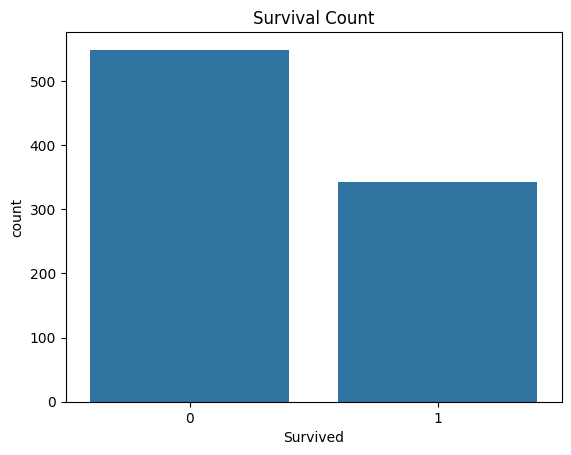

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

📊**1. Survival Count – Interpretation**

👉 Majority passengers survive aagala

👉 Death count > Survival count

👉 Overall survival rate low ah iruku

👉 Disaster impact romba severe

👉 Rescue limited ah irundhuchu

# ***👩‍🦰👨 2. Gender vs Survival***

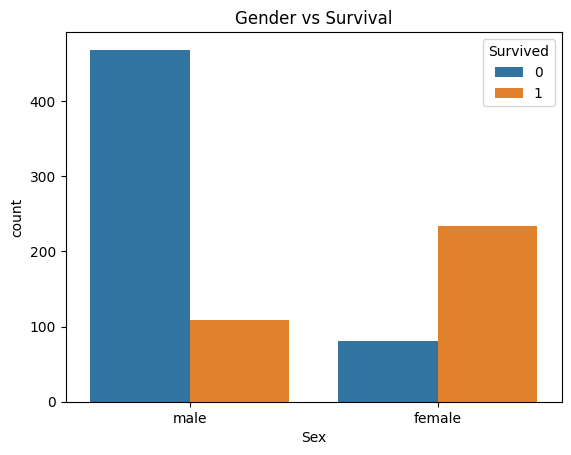

In [10]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Gender vs Survival")
plt.show()

**👩‍🦰👨 2. Gender vs Survival – Interpretation**

👉 Females survival adhigam 🔥

👉 Males la death rate romba high

👉 “Women first policy” follow pannirukaanga

👉 Female safety priority clear ah theriyuthu


👉 Gender strong factor in survival

# ***🎂 3. Age Distribution***

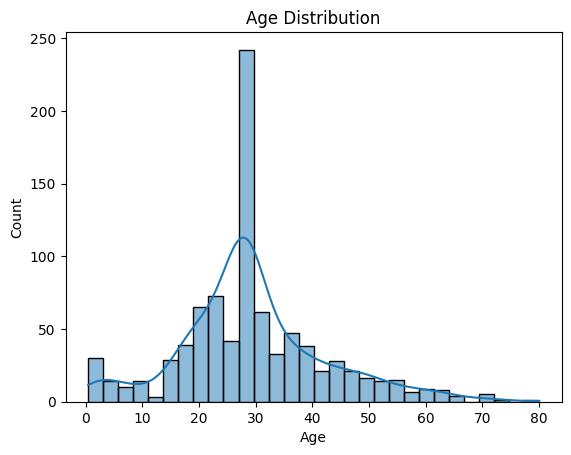

In [11]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

**🎂 3. Age Distribution – Interpretation**

👉 Most passengers young adults (20–35)

👉 Kids & old people kammi

👉 Age distribution slightly right skewed

👉 Majority working-age group

👉 No extreme imbalance

# ***💰 4. Fare Analysis***

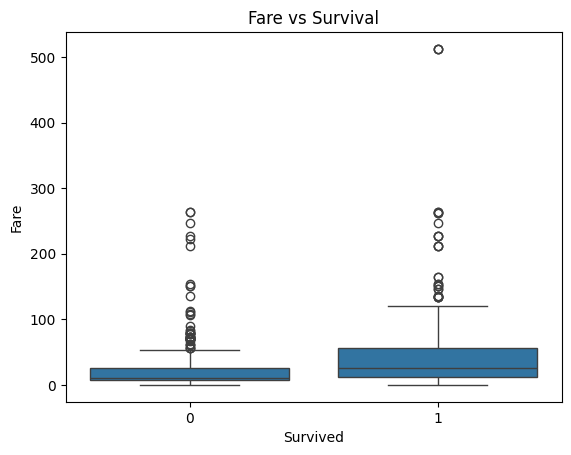

In [12]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

**💰 4. Fare vs Survival – Interpretation**

👉 High fare passengers more survival chances

👉 Low fare → more deaths

👉 Rich passengers safer ah irundhanga

👉 Class (Pclass) impact strong ah iruku

👉 Socio-economic factor important

# **Feature Engineering + ML Model**

In [14]:
#🔧 1. Unnecessary columns remove

df = df.drop(["PassengerId", "Name", "Ticket"], axis=1)

In [15]:
#🔄 2. Categorical → Numeric

# Convert Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Convert Embarked
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [17]:
#🎯 3. Features & Target split

X = df.drop("Survived", axis=1)
y = df["Survived"]

In [18]:
#✂️ 4. Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#🤖 5. Model Build (Logistic Regression)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
#📊 6. Prediction + Accuracy

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# **📊 Titanic Survival Prediction – Model Interpretation**

✅ **Overall Performance**

The model achieved an accuracy of 81%, indicating a strong ability to predict passenger survival. This is a solid result for a baseline classification model.

------------------------------------------------------------------

📌 **Class-wise Performance**

🔴 Not Survived (0)

* Precision: 0.83
* Recall: 0.86

The model effectively identifies passengers who did not survive, with high recall indicating fewer false negatives.

🟢 Survived (1)
* Precision: 0.79
* Recall: 0.74

The model performs reasonably well in predicting survivors, though there is slight room for improvement in recall.

-----------------------------------------------------------------

**⚖️ Model Evaluation**

* The model demonstrates a balanced performance across both classes.
* There is no significant sign of overfitting.
* The results are reliable for a real-world classification scenario at a beginner to intermediate level.

------------------------------------------------------------------

**🧠 Key Insights**

* Gender, fare, and passenger class (Pclass) are the most influential factors in determining survival.
* Female passengers and those who paid higher fares had a higher probability of survival.

------------------------------------------------------------------

🎯 **Final Conclusion**

* This project successfully demonstrates the end-to-end data science workflow, including data preprocessing, exploratory data analysis, feature engineering, and model building.

* The Logistic Regression model achieved a good balance between precision and recall, making it a dependable baseline model for survival prediction.